In [13]:
import importlib
import md_Helpers

importlib.reload(md_Helpers)

from md_Helpers import open_run

run = open_run("20260914204242")
#run.info()

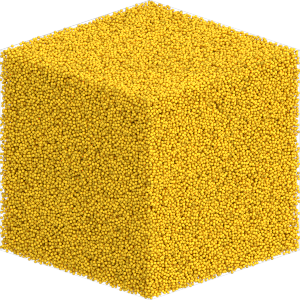

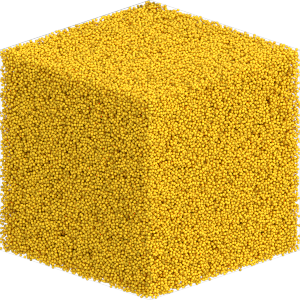

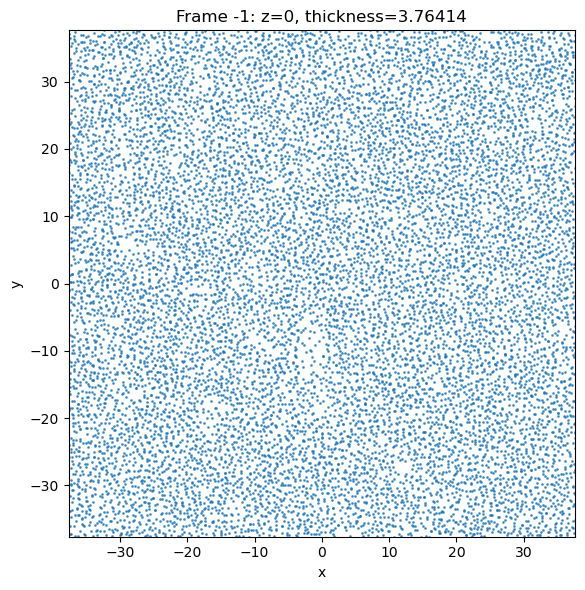

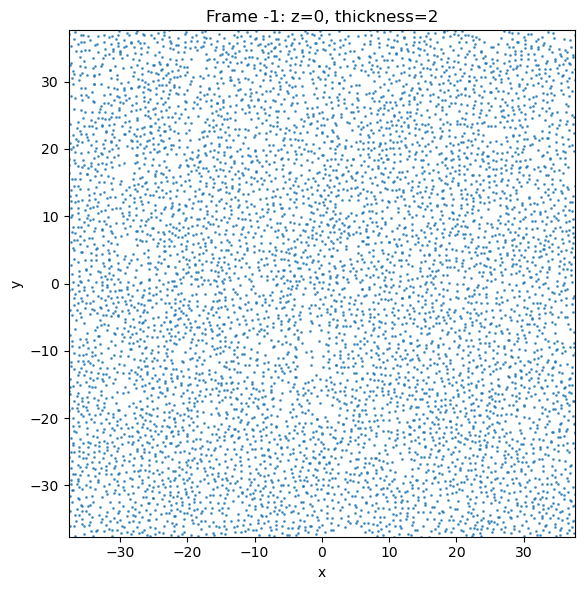

In [5]:
# 3D views
run.render(frame=0)
run.render(frame=-1)
#run.render_movie(frame_step=50)

# XY slices
run.xy_slice(frame=-1)
run.xy_slice(frame=-1, z=0, thickness=2.0);
#run.xy_slice(frames=[0, 10, 20, -1])
#run.xy_slice_movie(frame_step=25)

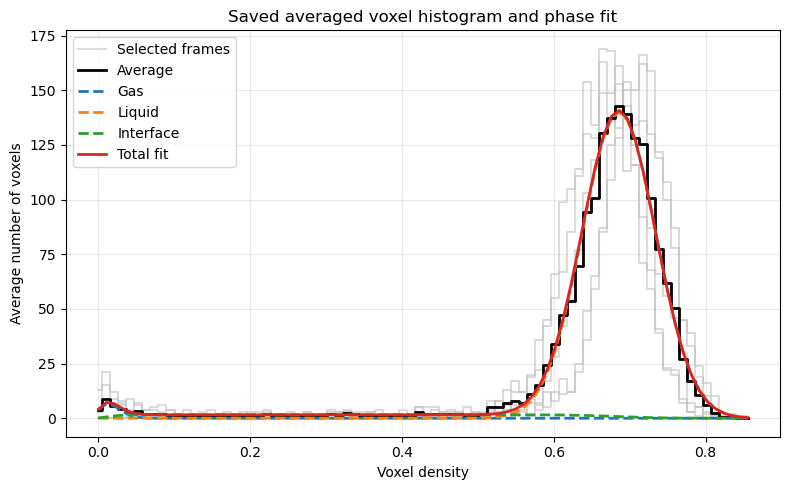

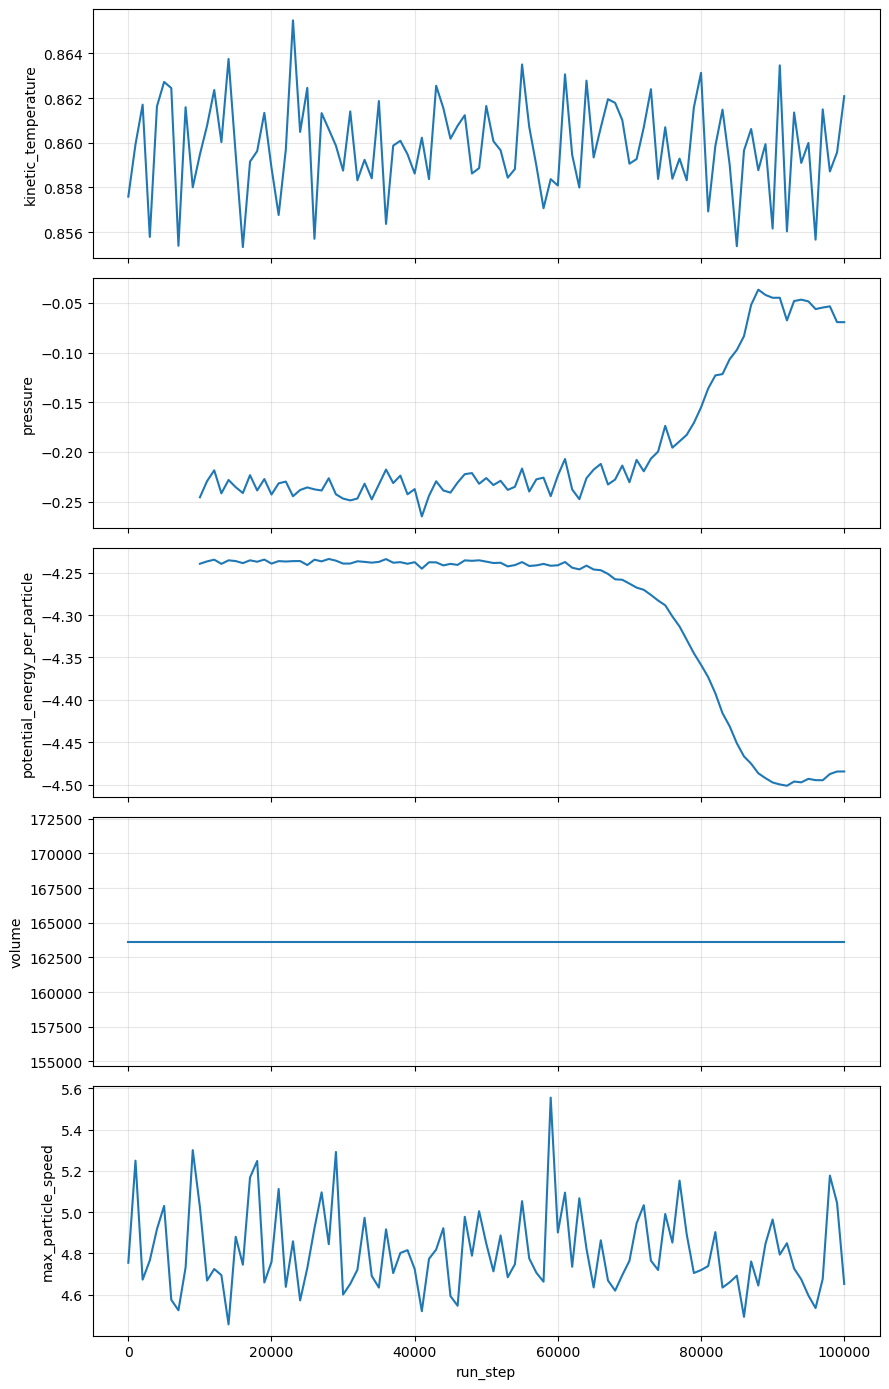

In [14]:
# Phase fit and logs
run.plot_phase_fit();
run.plot_logs();

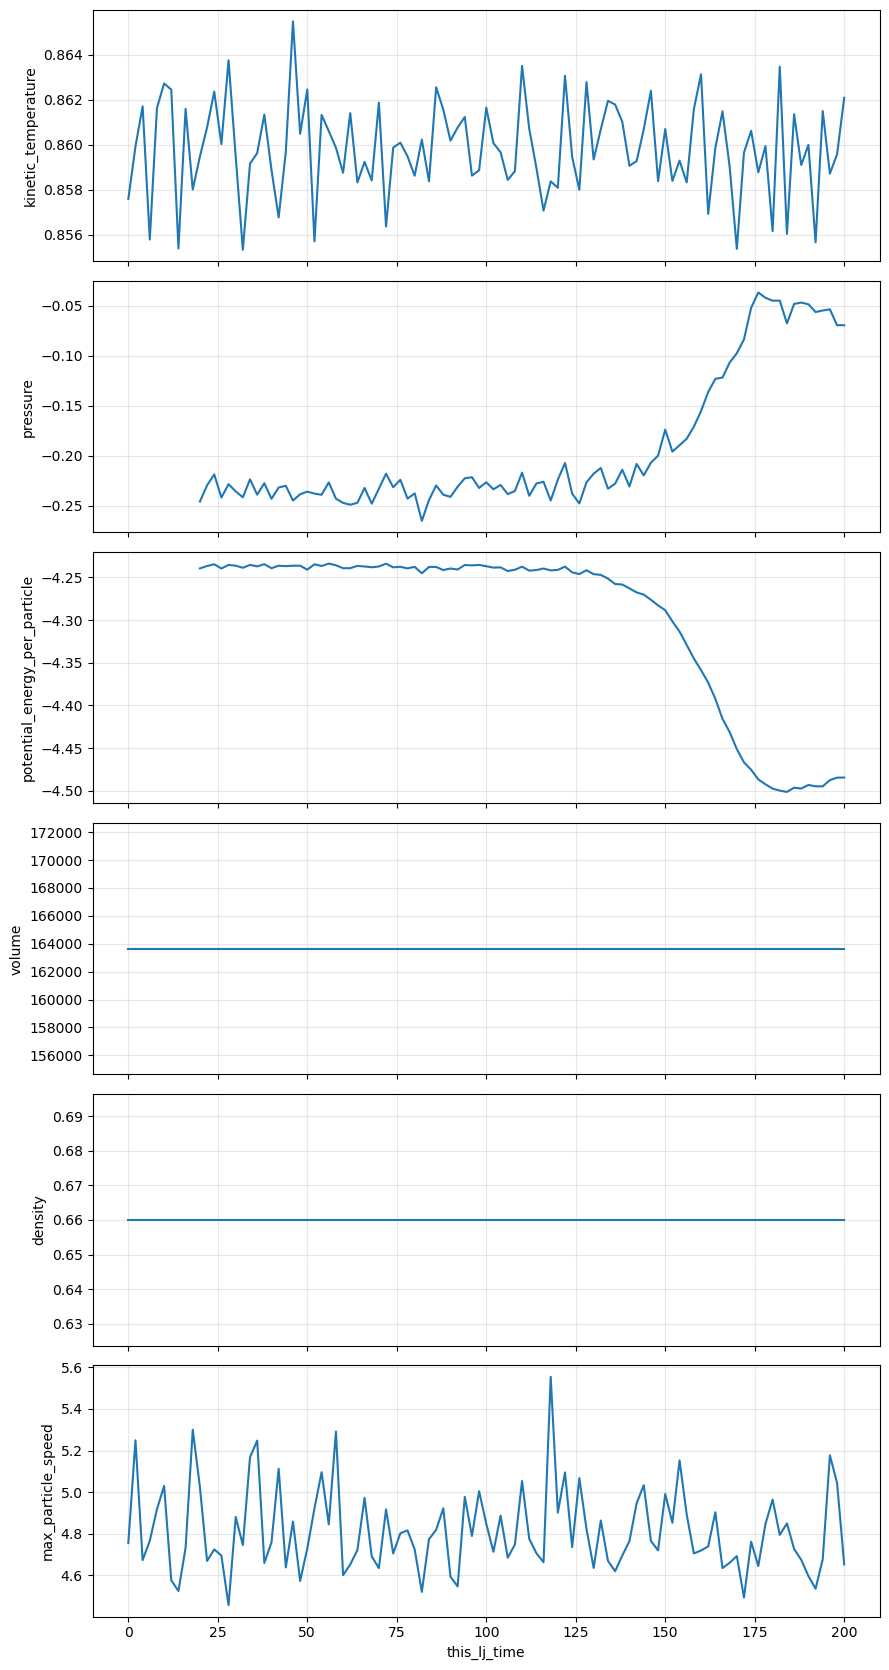

In [3]:
run.plot_logs(
    [
        "kinetic_temperature",
        "pressure",
        "potential_energy_per_particle",
        "volume",
        "density",
        "max_particle_speed",
    ],
    x="this_lj_time",
);

#x="frame"
#x="hoomd_timestep"
#x="run_step"
#x="this_lj_time"
#x="cumulative_lj_time"

In [5]:
logs = run.logs_dataframe()
metadata = run.metadata()
frame_table = run.frame_table()

for field, value in metadata.items():
    print(f"{field}: {value}")

mdsims/analysis/phase_fit/message: Voxel classification did not identify phase separation.
mdsims/analysis/phase_fit/status: Skipped_Homogeneous
mdsims/analysis/phase_separation/PE_drop/PE_drop: -0.22247797818040027
mdsims/analysis/phase_separation/PE_drop/PE_drop_z_score: -1.7272030339409603
mdsims/analysis/phase_separation/PE_drop/decision_rule: either
mdsims/analysis/phase_separation/PE_drop/drop_threshold: -0.15
mdsims/analysis/phase_separation/PE_drop/last_PE_per_particle_mean: -4.008274255819248
mdsims/analysis/phase_separation/PE_drop/last_PE_per_particle_std: 0.1288082372532499
mdsims/analysis/phase_separation/PE_drop/method: PE_drop
mdsims/analysis/phase_separation/PE_drop/method_version: pe_drop_v1
mdsims/analysis/phase_separation/PE_drop/n_last: 51
mdsims/analysis/phase_separation/PE_drop/passes_drop_threshold: True
mdsims/analysis/phase_separation/PE_drop/passes_z_limit: False
mdsims/analysis/phase_separation/PE_drop/phase_separated: True
mdsims/analysis/phase_separation/PE

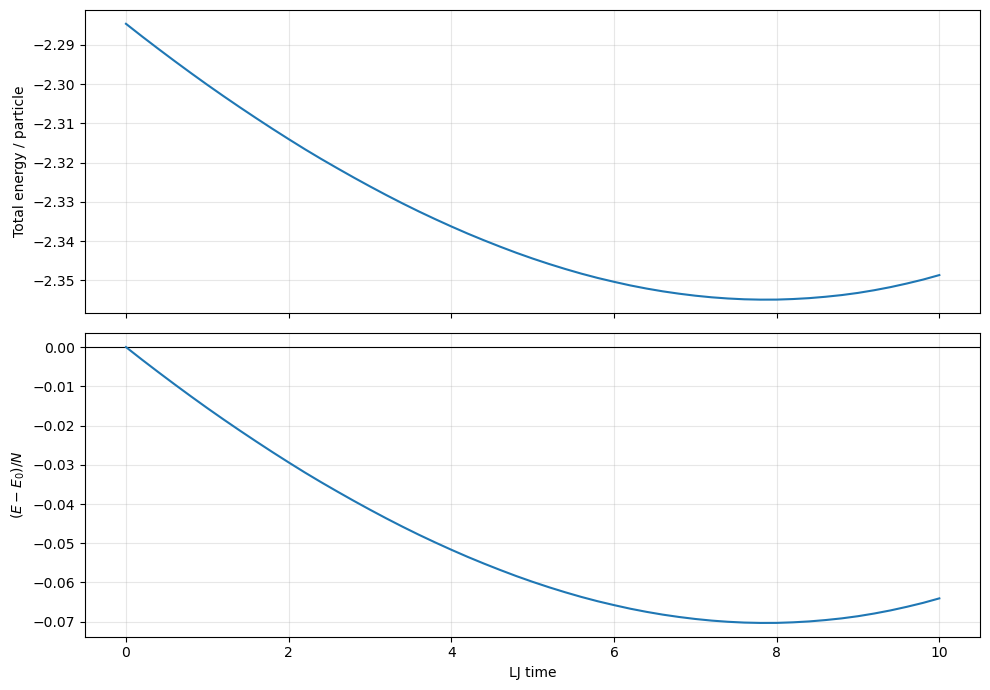

In [6]:
import matplotlib.pyplot as plt

logs = run.logs_dataframe()

logs["total_energy"] = (
    logs["kinetic_energy"]
    + logs["potential_energy"]
)

logs["total_energy_per_particle"] = (
    logs["total_energy"]
    / logs["num_particles"]
)

initial_energy = logs["total_energy_per_particle"].iloc[0]

logs["energy_change_per_particle"] = (
    logs["total_energy_per_particle"]
    - initial_energy
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(
    logs["this_lj_time"],
    logs["total_energy_per_particle"],
)

axes[0].set_ylabel("Total energy / particle")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].plot(
    logs["this_lj_time"],
    logs["energy_change_per_particle"],
)

axes[1].set_xlabel("LJ time")
axes[1].set_ylabel(r"$(E-E_0)/N$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()